# 4.2 The Image Classification Dataset

Before training a classifier we need data. We use **Fashion-MNIST** — a drop-in
replacement for the classic MNIST digits, but harder and more representative of
real images. It has **10 clothing categories**, each a $28 \times 28$ grayscale
image, with **60,000** training and **10,000** test examples.

We wrap it in a `d2l.DataModule` so it plugs straight into the same `Trainer`
we used for regression.

Everything in this section stays on the **CPU**: the `transforms` pipeline and
the `DataLoader`'s `num_workers` are CPU-side parallelism, and every tensor we
print below lives on `cpu`. The GPU only enters the picture once a model is
handed to the `Trainer`, in a later section.

In [1]:
%matplotlib inline
import time
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()   # render figures as crisp SVG in the notebook

## 4.2.1 Loading the Dataset

`torchvision` can download Fashion-MNIST for us. We build a small transform
pipeline — optionally **resize**, then convert to a tensor (which also scales
pixel values from `0-255` into the `0.0-1.0` range) — and grab both the training
and test splits.

`resize` is a free hyperparameter: it fixes the output `(height, width)`, so it
directly controls the image shape you'll see below. Fashion-MNIST's native
resolution is $28 \times 28$; passing `resize=(32, 32)` upsamples every image.

In [2]:
class FashionMNIST(d2l.DataModule):  #@save
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()                 # store batch_size, resize
        trans = transforms.Compose([
            transforms.Resize(resize),              # optional resize (H, W)
            transforms.ToTensor()])                 # PIL image -> float tensor in [0, 1]
        self.train = torchvision.datasets.FashionMNIST(
            root=self.root, train=True, transform=trans, download=True)   # 60k train
        self.val = torchvision.datasets.FashionMNIST(
            root=self.root, train=False, transform=trans, download=True)  # 10k test

In [3]:
data = FashionMNIST(resize=(32, 32))  # native resolution is 28x28; resize upsamples here
print('train / val sizes:', len(data.train), len(data.val))
# each item is (image, label); image shape = (channels, height, width)
print('image shape:', data.train[0][0].shape)   # (1, 32, 32) -> 1 grayscale channel, upsampled from 28x28
print('label:', data.train[0][1])               # an int in 0..9

train / val sizes: 60000 10000
image shape: torch.Size([1, 32, 32])
label: 9


The labels are integers `0-9`. Since the classes have no numeric meaning, it
helps to map them to human-readable names for inspection.

In [4]:
@d2l.add_to_class(FashionMNIST)  #@save
def text_labels(self, indices):
    """Map numeric class indices to their text labels."""
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[int(i)] for i in indices]

print(data.text_labels([0, 3, 8, 9]))   # -> ['t-shirt', 'dress', 'bag', 'ankle boot']

['t-shirt', 'dress', 'bag', 'ankle boot']


## 4.2.2 Reading a Minibatch

`get_dataloader` wraps a split in a PyTorch `DataLoader`, which shuffles (for
training) and serves the data in mini-batches. `num_workers` spawns that many
background **CPU** processes to prefetch batches in parallel — pure CPU-side
parallelism that pays off once a GPU is doing the heavy lifting later and would
otherwise sit idle waiting for the next batch.

In [5]:
@d2l.add_to_class(FashionMNIST)  #@save
def get_dataloader(self, train):
    data = self.train if train else self.val               # pick the split
    return torch.utils.data.DataLoader(
        data, self.batch_size, shuffle=train,              # shuffle only when training
        num_workers=self.num_workers)                      # parallel batch loading

In [6]:
X, y = next(iter(data.train_dataloader()))   # grab one mini-batch
print('X:', X.shape, X.dtype, X.device)   # (batch, 1, 32, 32), float32, cpu
print('y:', y.shape, y.dtype, y.device)   # (batch,), int64 class labels, cpu

X: torch.Size([64, 1, 32, 32]) torch.float32 cpu
y: torch.Size([64]) torch.int64 cpu


In [7]:
# How long does one full pass over the training set take (num_workers=4, the d2l default)?
tic = time.time()
for X, y in data.train_dataloader():
    continue
f'{time.time() - tic:.2f} sec per epoch of data loading'

'1.73 sec per epoch of data loading'

In [8]:
# Exercise check: does num_workers actually help, or is the dataset small enough
# that process-spawning overhead cancels out the parallelism? Compare against a
# single-process loader (num_workers=0).
for num_workers in (0, data.num_workers):
    loader = torch.utils.data.DataLoader(
        data.train, data.batch_size, shuffle=True, num_workers=num_workers)
    tic = time.time()
    for X, y in loader:
        continue
    print(f'num_workers={num_workers}: {time.time() - tic:.2f} sec per epoch')

num_workers=0: 3.02 sec per epoch


num_workers=4: 1.72 sec per epoch


## 4.2.3 Visualization

A quick sanity check: display a batch of images with their labels. Reusing the
d2l helper `show_images`, we squeeze out the single channel dimension so each
image is a plain 2-D grid.

`show_images` only fills as many slots as `nrows * ncols` — it zips the grid's
axes with the batch and silently drops whatever doesn't fit. With the default
`nrows=1, ncols=8` that's just 8 of the 64 images in a batch; size the grid to
`batch_size` (e.g. `nrows=8, ncols=8` below) to see the whole thing.

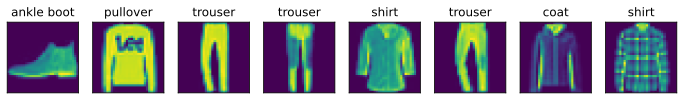

In [9]:
@d2l.add_to_class(FashionMNIST)  #@save
def visualize(self, batch, nrows=1, ncols=8, labels=[]):
    X, y = batch
    if not labels:
        labels = self.text_labels(y)                 # default: use the true labels
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)  # drop channel dim

batch = next(iter(data.val_dataloader()))
data.visualize(batch)

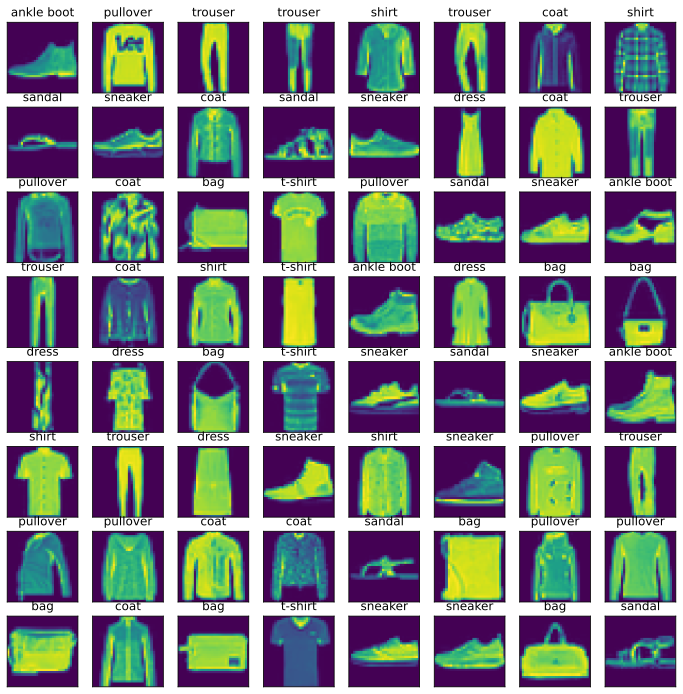

In [10]:
# The 64-image batch in full -- grid size (8, 8) matches batch_size exactly.
data.visualize(batch, nrows=8, ncols=8)

## 4.2.4 Summary

- **Fashion-MNIST** — 10 clothing classes, $28\times28$ grayscale, 60k train /
  10k test — a modest but non-trivial image-classification benchmark.
- Wrapping it as a `d2l.DataModule` gives us `train_dataloader()` /
  `val_dataloader()` that feed shuffled mini-batches straight into the `Trainer`.
- `ToTensor()` rescales pixels to $[0, 1]$; `text_labels` turns numeric classes
  into readable names; `visualize` sanity-checks a batch.
- Everything here — transforms, `num_workers` prefetching, the tensors
  themselves — runs on the **CPU**; the GPU only appears once a model reaches
  the `Trainer`.
- `show_images` draws exactly `nrows * ncols` images, so size the grid to
  however much of a batch you actually want to see.
- With the data ready, the next section defines a reusable **base classifier**
  that measures loss *and* accuracy.